# 02 · Grad-CAM Explanations for the ELPV Fault Classifier

This notebook loads the fine-tuned ResNet18 classifier and visualizes where it attends
when classifying a solar cell. Grad-CAM produces a heatmap over the input by weighting the
last convolutional feature maps by the gradient of the predicted class, highlighting the
regions most responsible for the prediction.

The objective is to confirm the model localizes genuine defect regions (cracks, dark or
disconnected areas) on faulty cells rather than relying on spurious cues.

## 1. Imports and path setup

The notebook runs from `notebooks/`, so we locate the repository root and add `src/` to
`sys.path` to import the project's model and data utilities. We also import Grad-CAM from
`pytorch_grad_cam`.

In [1]:
import sys
from pathlib import Path

# Locate the repo root by searching upward for src/model.py, then expose src/ for import.
_cwd = Path.cwd().resolve()
REPO_ROOT = next(c for c in [_cwd, *_cwd.parents] if (c / "src" / "model.py").exists())
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

from model import build_model, get_device
from dataset import get_dataloaders, get_transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

%matplotlib inline

## 2. Load the fine-tuned model

We rebuild the architecture and unfreeze `layer4` to match the fine-tuned checkpoint, then
load `models/best_model_finetuned.pth`. Unfreezing `layer4` is also required for Grad-CAM:
the target layer's activations must carry gradients for the backward pass to produce a
heatmap. The model is moved to the best available device and set to eval mode.

In [2]:
CLASS_NAMES = ["healthy", "faulty"]
CHECKPOINT = REPO_ROOT / "models" / "best_model_finetuned.pth"

device = get_device()
print(f"Device: {device}")

model = build_model(num_classes=2, freeze_backbone=True)
# Match the fine-tuned checkpoint and enable gradients through the Grad-CAM target layer.
for param in model.layer4.parameters():
    param.requires_grad = True

model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.to(device)
model.eval()
print(f"Loaded checkpoint: {CHECKPOINT.relative_to(REPO_ROOT)}")

Device: mps


Loaded checkpoint: models/best_model_finetuned.pth


## 3. Rebuild the test split

We rebuild the dataloaders with the same `seed=42` used during training so the test split
is identical to the one the model was evaluated on. We only need the test DataFrame here,
to select specific images by true label.

In [3]:
CSV_PATH = REPO_ROOT / "data" / "labels_binary.csv"

_, _, _, _, _, test_df = get_dataloaders(CSV_PATH, batch_size=32, seed=42)
print(f"Test split: {len(test_df)} images")
print(test_df["label"].value_counts().rename(index={0: "healthy", 1: "faulty"}))

Test split: 394 images
label
healthy    271
faulty     123
Name: count, dtype: int64


## 4. The `explain_image` function

`explain_image` preprocesses an image with the evaluation transform, predicts its class and
softmax confidence, and computes a Grad-CAM heatmap targeting ResNet18's last convolutional
block (`model.layer4[-1]`). The heatmap is overlaid on the un-normalized `[0, 1]` image so
the colors render correctly. It returns the display image, the overlay, the predicted
label, and the confidence.

In [4]:
from torchvision import transforms

# Normalized transform for the model input; resize-only transform for the display image.
_, eval_transform = get_transforms()
display_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Target the last conv block; reused across calls so hooks are registered once.
cam = GradCAM(model=model, target_layers=[model.layer4[-1]])


def explain_image(image_path):
    """Return (display_rgb, overlay, predicted_label, confidence) for one image."""
    image = Image.open(image_path).convert("RGB")

    input_tensor = eval_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(input_tensor), dim=1)[0]
    pred = int(probs.argmax())
    confidence = float(probs[pred])

    # Grad-CAM for the predicted class; returns a [0, 1] heatmap at input resolution.
    grayscale_cam = cam(input_tensor=input_tensor,
                        targets=[ClassifierOutputTarget(pred)])[0]

    # float32 [0, 1] HxWx3 image for the overlay.
    display_rgb = display_transform(image).permute(1, 2, 0).numpy().astype(np.float32)
    overlay = show_cam_on_image(display_rgb, grayscale_cam, use_rgb=True)

    return display_rgb, overlay, CLASS_NAMES[pred], confidence

## 5. Grad-CAM grid: faulty and healthy cells

We select four faulty and four healthy cells from the test split and show each original
next to its Grad-CAM overlay. Titles report the true label, the predicted label, and the
model's confidence. Warm regions in the overlay indicate the areas that most influenced the
prediction.

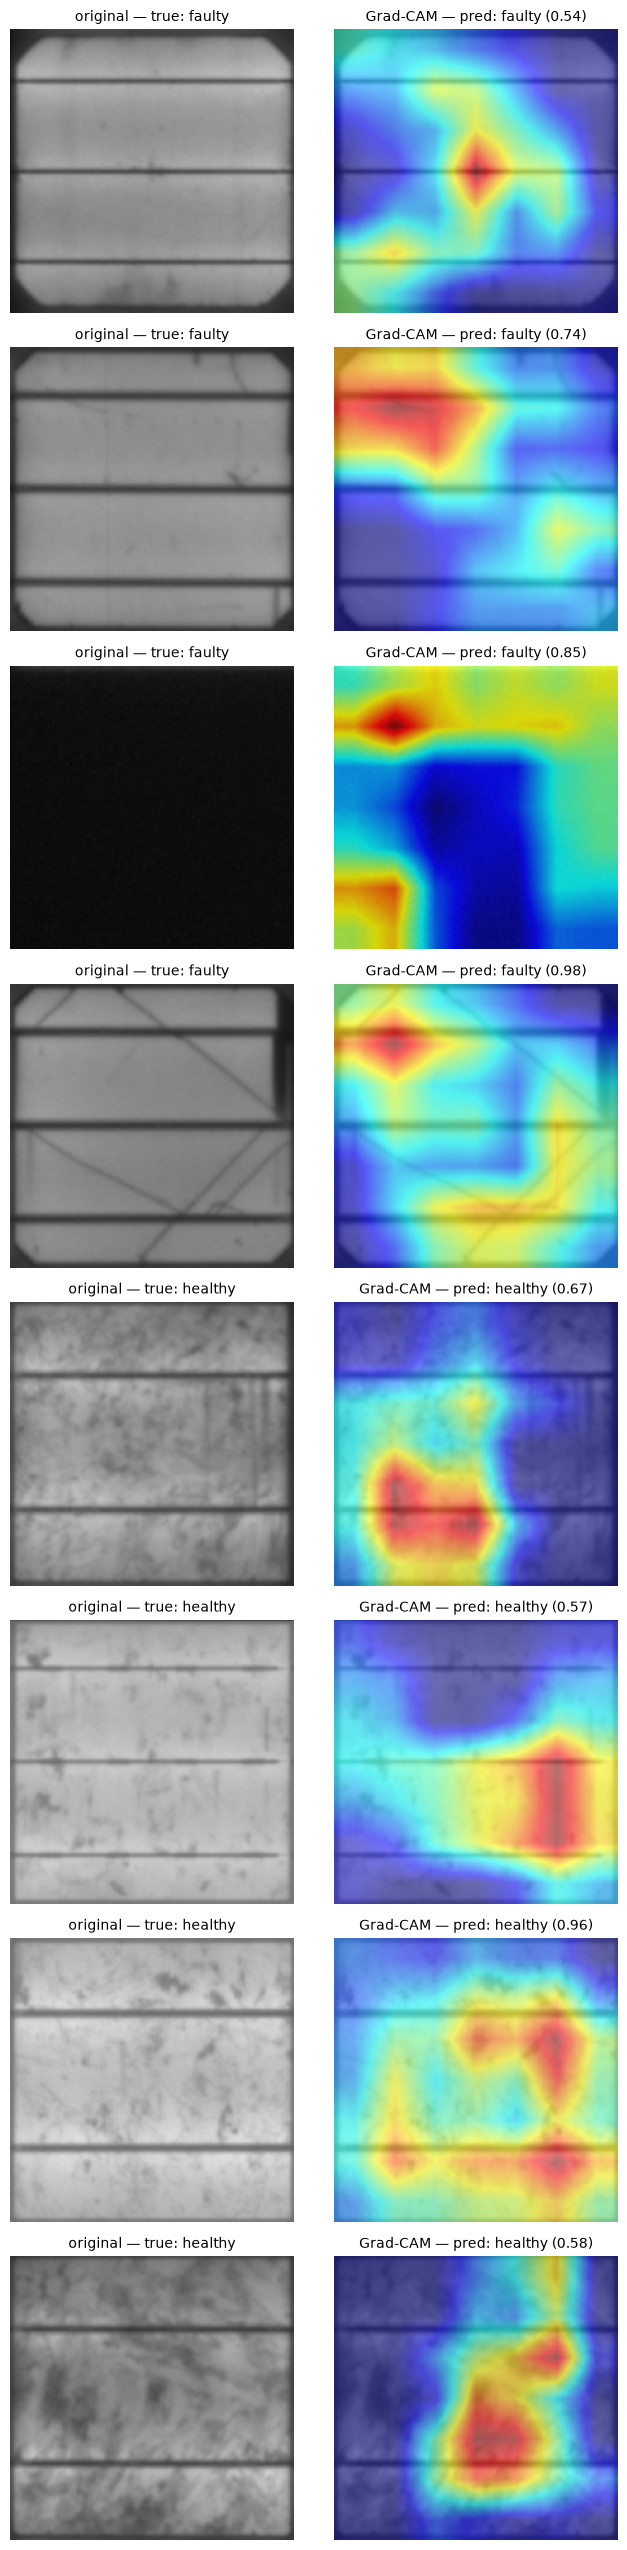

In [5]:
faulty_paths = test_df[test_df["label"] == 1]["full_path"].head(4).tolist()
healthy_paths = test_df[test_df["label"] == 0]["full_path"].head(4).tolist()
samples = [(p, 1) for p in faulty_paths] + [(p, 0) for p in healthy_paths]

fig, axes = plt.subplots(len(samples), 2, figsize=(7, 3.2 * len(samples)))
for row, (path, true_label) in enumerate(samples):
    display_rgb, overlay, pred_label, confidence = explain_image(path)

    axes[row, 0].imshow(display_rgb)
    axes[row, 0].set_title(f"original — true: {CLASS_NAMES[true_label]}", fontsize=10)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(
        f"Grad-CAM — pred: {pred_label} ({confidence:.2f})", fontsize=10)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## 6. Summary

All eight sample cells were classified correctly. Several faulty predictions, however, were
low-confidence (0.54–0.74), so those explanations rest on borderline decisions and should be
weighted accordingly.

Grad-CAM is min-max normalized per image, so every map contains a full-intensity peak by
construction. The heatmap therefore indicates where the evidence for the predicted class is
concentrated, not the severity or presence of a defect; it does not go quiet on healthy
cells, and the healthy examples here exhibit peaks comparable to the faulty ones.

On faulty cells the peak is sometimes on or near a visible defect and sometimes not clearly
aligned with one. Uniformly dead or disconnected cells tend to draw activation toward the
edges, since there is no localized lesion to attend to.

These overlays are useful as an inspection-assist signal that directs a reviewer's
attention, but should not be read as a calibrated defect localizer.